# Day 57: KNN — sklearn + Cross-Validation for K Selection
**Phase 4 · Machine Learning** | Datasets: FC Lahore Lions players (synthetic, seed = 42) and sklearn's Wine dataset

## Objective
By the end of this notebook I should be able to:
- Build a baseline KNN with `KNeighborsClassifier(n_neighbors=5).fit().predict()`
- Use `cross_val_score()` to test K = 1 to 20 and plot **K vs accuracy** to find the **elbow**
- Scale with `StandardScaler` and **fit it on training data only**, even inside cross-validation
- Report the final **test accuracy and a classification report** for a K chosen by CV

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# KNN, scaling, pipeline, splitting and evaluation tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

plt.rcParams["axes.grid"] = True

## Theory
- **Recap (Day 56):** KNN predicts by majority vote of the K nearest points, and it needs **scaled features**.
- **Problem:** how do we pick K? Trying K values and checking the **test set** each time leaks test information. That is guessing.
- **Cross-validation (CV):**
  - Split the training data into 5 parts (folds).
  - Train on 4 folds, score on the 1 left out. Repeat so every fold gets one turn as the "mini test set".
  - Average the 5 scores. That average is steadier than a single split.
- **`cross_val_score(model, X, y, cv=5)`** does all of this and returns 5 scores.
- **Scaling inside CV:** if you scale the whole training set first, every fold's scaler has already seen the left-out fold. A **pipeline** chains `StandardScaler` and the model, so the scaler is **re-fit on the training folds only**, every time. (Full pipelines come later; today I only use `make_pipeline`.)
- **Elbow:** as K grows, CV accuracy usually rises then flattens. The elbow is where extra K stops paying off. Rule used here: the **smallest K whose mean CV accuracy is within 1 standard deviation of the best**.
- **The test set is used once**, at the very end.

**Football picture:** 5-fold CV is like scouting a player over 5 different matches instead of judging him on one. One match can be lucky or unlucky; the average across five is fairer.

## Example 1: Baseline KNN

In [2]:
# Synthetic data: 300 players. Target: is_winger (1 = winger, 0 = centre back)
rng = np.random.default_rng(42)                        # seed = 42 so results repeat
n_players = 300
is_winger = rng.integers(0, 2, size=n_players)

# Wingers: faster, win fewer aerial duels, cross more. Minutes has NO link to the role.
speed = np.where(is_winger == 1, rng.normal(31.5, 1.8, n_players), rng.normal(29.0, 1.8, n_players)).round(1)
aerial = np.clip(np.where(is_winger == 1, rng.normal(2.2, 1.0, n_players), rng.normal(4.2, 1.4, n_players)), 0, None).round(1)
crosses = np.clip(np.where(is_winger == 1, rng.normal(2.2, 1.1, n_players), rng.normal(0.9, 0.7, n_players)), 0, None).round(1)
minutes = rng.integers(500, 3001, size=n_players)

df = pd.DataFrame({
    "player_id": np.arange(1, n_players + 1),
    "sprint_speed_kmh": speed,
    "aerial_duels_won": aerial,
    "crosses_per_90": crosses,
    "minutes_played": minutes,
    "is_winger": is_winger
})

# Save next to the notebook, then read it back
df.to_csv("day_57_fc_lahore_lions_players.csv", index=False)
df = pd.read_csv("day_57_fc_lahore_lions_players.csv")
print(df.head())

   player_id  sprint_speed_kmh  aerial_duels_won  crosses_per_90  \
0          1              31.0               2.9             0.8   
1          2              31.8               1.3             2.1   
2          3              31.2               2.2             1.9   
3          4              29.6               3.9             1.8   
4          5              32.5               4.4             1.3   

   minutes_played  is_winger  
0            1275          0  
1             678          1  
2            1538          1  
3            1688          0  
4            2386          0  


In [3]:
# Features (X) and target (y), then a stratified 75/25 split
X = df[["sprint_speed_kmh", "aerial_duels_won", "crosses_per_90", "minutes_played"]]
y = df["is_winger"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 225 | Test: 75


In [4]:
# Baseline: scale (fit on TRAIN only), then KNN with K = 5
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
print("Baseline test accuracy:", round(knn.score(X_test_s, y_test), 3))

Baseline test accuracy: 0.893


## Example 2: Cross-Validation to Choose K

### 2A. cross_val_score on one K

In [5]:
# 5-fold CV on the TRAIN set for K = 5. One score per fold.
# (Scaled BEFORE cross-validation - this is the leaky way, shown for comparison.)
knn5 = KNeighborsClassifier(n_neighbors=5)
scores_leaky = cross_val_score(knn5, X_train_s, y_train, cv=5)
print("Fold scores:", scores_leaky.round(3))
print("Mean:", round(scores_leaky.mean(), 3), "| Std:", round(scores_leaky.std(), 3))

Fold scores: [0.889 0.756 0.867 0.733 0.822]
Mean: 0.813 | Std: 0.061


### 2B. Scaling inside every fold with a pipeline

In [6]:
# The pipeline re-fits the scaler on the training folds only, every time
pipe = make_pipeline(StandardScaler(),
                     KNeighborsClassifier(5))
scores = cross_val_score(pipe, X_train, y_train, cv=5)      # note: RAW X_train here
print("Fold scores:", scores.round(3))
print("Mean:", round(scores.mean(), 3), "| Std:", round(scores.std(), 3))

# The fold scores vary a lot: this is why one split alone is not reliable.

Fold scores: [0.889 0.756 0.867 0.756 0.822]
Mean: 0.818 | Std: 0.055


### 2C. Test K = 1 to 20 and find the elbow

In [7]:
# CV accuracy for K = 1 to 20 (scaling inside each fold)
k_values = list(range(1, 21))
means, stds = [], []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    pipe_k = make_pipeline(StandardScaler(), knn_k)
    s = cross_val_score(pipe_k, X_train, y_train, cv=5)
    means.append(s.mean())
    stds.append(s.std())

for k, m, sd in zip(k_values, means, stds):
    print(f"K = {k:>2} | mean CV accuracy = {m:.3f} | std = {sd:.3f}")

best_idx = int(np.argmax(means))
print("\nHighest mean:", round(means[best_idx], 3), "at K =", k_values[best_idx])

K =  1 | mean CV accuracy = 0.836 | std = 0.057
K =  2 | mean CV accuracy = 0.844 | std = 0.044
K =  3 | mean CV accuracy = 0.831 | std = 0.061
K =  4 | mean CV accuracy = 0.849 | std = 0.043
K =  5 | mean CV accuracy = 0.818 | std = 0.055
K =  6 | mean CV accuracy = 0.849 | std = 0.029
K =  7 | mean CV accuracy = 0.836 | std = 0.067
K =  8 | mean CV accuracy = 0.862 | std = 0.043
K =  9 | mean CV accuracy = 0.858 | std = 0.050
K = 10 | mean CV accuracy = 0.867 | std = 0.024
K = 11 | mean CV accuracy = 0.858 | std = 0.036
K = 12 | mean CV accuracy = 0.871 | std = 0.033
K = 13 | mean CV accuracy = 0.862 | std = 0.060
K = 14 | mean CV accuracy = 0.871 | std = 0.033
K = 15 | mean CV accuracy = 0.876 | std = 0.044
K = 16 | mean CV accuracy = 0.871 | std = 0.029
K = 17 | mean CV accuracy = 0.858 | std = 0.036
K = 18 | mean CV accuracy = 0.867 | std = 0.024
K = 19 | mean CV accuracy = 0.867 | std = 0.024
K = 20 | mean CV accuracy = 0.880 | std = 0.027

Highest mean: 0.88 at K = 20


In [8]:
# Elbow rule: the smallest K whose mean is within 1 std of the best mean
cutoff = means[best_idx] - stds[best_idx]
for k, m in enumerate(means, start=1):
    if m >= cutoff:
        elbow_k = k
        break
print("Cutoff:", round(cutoff, 3))
print("Elbow K:", elbow_k, "| mean CV accuracy:", round(means[elbow_k - 1], 3))

Cutoff: 0.853
Elbow K: 8 | mean CV accuracy: 0.862


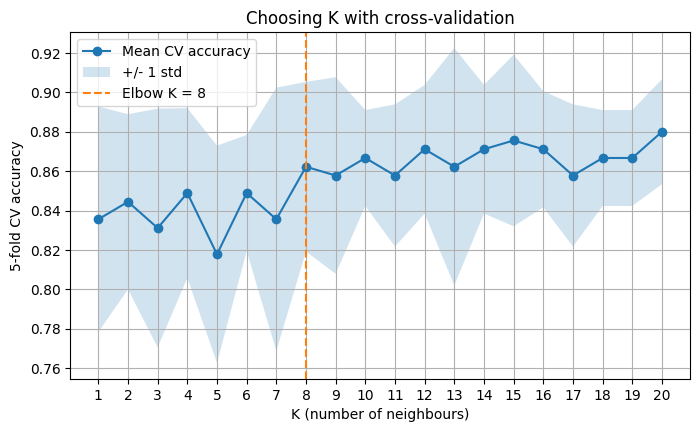

In [9]:
# Chart: K vs CV accuracy with a +/- 1 std band
means_arr = np.array(means)
stds_arr = np.array(stds)

plt.figure(figsize=(8, 4.5))
plt.plot(k_values, means_arr, marker="o", label="Mean CV accuracy")
plt.fill_between(k_values, means_arr - stds_arr, means_arr + stds_arr, alpha=0.2, label="+/- 1 std")
plt.axvline(elbow_k, color="tab:orange", linestyle="--", label=f"Elbow K = {elbow_k}")
plt.xticks(k_values)
plt.xlabel("K (number of neighbours)")
plt.ylabel("5-fold CV accuracy")
plt.title("Choosing K with cross-validation")
plt.legend()
plt.savefig("images/k_vs_cv_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

### 2D. Final model: train on the full training set, test ONCE

In [10]:
# Retrain on the FULL training set with the CV-chosen K, then use the test set once
final = make_pipeline(StandardScaler(),
                      KNeighborsClassifier(n_neighbors=elbow_k))
final.fit(X_train, y_train)
print("Chosen K:", elbow_k)
print("Test accuracy:", round(final.score(X_test, y_test), 3))

Chosen K: 8
Test accuracy: 0.907


In [11]:
# Classification report (precision, recall, F1 from Day 55)
y_pred = final.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91        39
           1       0.91      0.89      0.90        36

    accuracy                           0.91        75
   macro avg       0.91      0.91      0.91        75
weighted avg       0.91      0.91      0.91        75



## Practice Exercise
**Your turn (Practice).** Use sklearn's **Wine** dataset (`load_wine`, 3 wine classes, 13 numeric features):
1. Split into train and test (`stratify`, `random_state=42`).
2. Tune K from 1 to 20 with 5-fold CV, using a pipeline with `StandardScaler`.
3. Pick K with the elbow rule, retrain on the full training set and report **test accuracy plus a classification report**.

In [12]:
# Your attempt here

In [13]:
# Worked answer
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
Xw, yw = wine.data, wine.target

# 1. Split
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.25, random_state=42, stratify=yw
)

# 2. CV for K = 1 to 20 with scaling inside each fold
w_means, w_stds = [], []
for k in range(1, 21):
    pipe_w = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    s = cross_val_score(pipe_w, Xw_train, yw_train, cv=5)
    w_means.append(s.mean())
    w_stds.append(s.std())

# 3. Elbow rule, retrain, test once
w_best = int(np.argmax(w_means))
w_cutoff = w_means[w_best] - w_stds[w_best]
for k, m in enumerate(w_means, start=1):
    if m >= w_cutoff:
        wine_k = k
        break

wine_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=wine_k))
wine_model.fit(Xw_train, yw_train)

print("Best mean CV accuracy:", round(w_means[w_best], 3), "at K =", w_best + 1)
print("Elbow K:", wine_k)
print("Test accuracy:", round(wine_model.score(Xw_test, yw_test), 3))
print()
print(classification_report(yw_test, wine_model.predict(Xw_test), target_names=wine.target_names))

Best mean CV accuracy: 0.977 at K = 15
Elbow K: 3
Test accuracy: 0.956

              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.89      0.94        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



## Mini Challenge
**Scaling on Wine.** Wine has features on very different scales (for example `proline` is in the hundreds or thousands, while others are below 10).
Compare 5-fold CV accuracy for K = 5 **without** scaling and **with** scaling, and draw a bar chart.

Feature ranges (max):
proline              1515.0
magnesium             162.0
alcalinity_of_ash      30.0
dtype: float64

Unscaled mean CV accuracy: 0.677
Scaled mean CV accuracy:   0.955


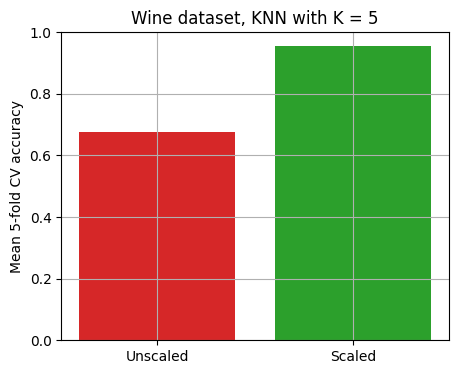

In [14]:
# Mini Challenge solution
print("Feature ranges (max):")
print(Xw_train.max().sort_values(ascending=False).head(3).round(1))

# K = 5, 5-fold CV, without and with scaling
raw_scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), Xw_train, yw_train, cv=5)
scaled_scores = cross_val_score(
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    Xw_train, yw_train, cv=5
)
print("\nUnscaled mean CV accuracy:", round(raw_scores.mean(), 3))
print("Scaled mean CV accuracy:  ", round(scaled_scores.mean(), 3))

plt.figure(figsize=(5, 4))
plt.bar(["Unscaled", "Scaled"], [raw_scores.mean(), scaled_scores.mean()], color=["tab:red", "tab:green"])
plt.ylim(0, 1)
plt.ylabel("Mean 5-fold CV accuracy")
plt.title("Wine dataset, KNN with K = 5")
plt.savefig("images/wine_scaled_vs_unscaled.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary
- Baseline: `KNeighborsClassifier(n_neighbors=5).fit().predict()` on scaled data.
- **Cross-validation** gives a steadier score than one split, and `cross_val_score(model, X, y, cv=5)` does it in one line.
- Put `StandardScaler` **inside a pipeline** so it is fitted on the training folds only.
- Plot K vs CV accuracy, choose the elbow, retrain on the full training set and score the **test set once**.
- Report more than accuracy: the **classification report** shows precision, recall and F1 per class.
- **Next: Day 58 — Decision Tree: entropy and information gain (theory).**